# 图表反演

In [1]:
import matplotlib.pyplot as plt
# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

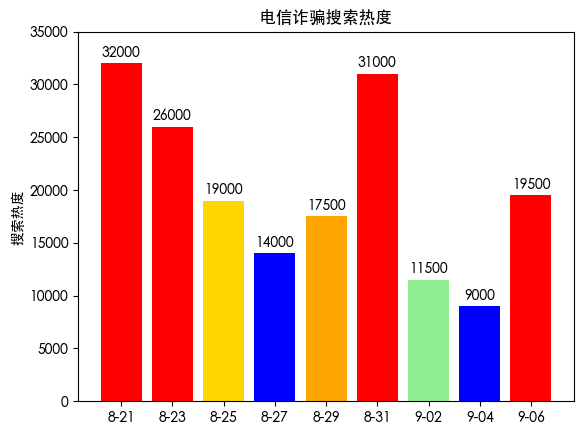

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 日期数据
dates = ['8-21', '8-23', '8-25', '8-27', '8-29', '8-31', '9-02', '9-04', '9-06']
# 搜索热度数据，可根据实际图表准确数值调整，这里为示意
search_heat = [32000, 26000, 19000, 14000, 17500, 31000, 11500, 9000, 19500]

x = np.arange(len(dates))  # x轴坐标

fig, ax = plt.subplots()
# 绘制柱状图
rects = ax.bar(x, search_heat, color=['r', 'r', 'gold', 'b', 'orange', 'r', 'lightgreen', 'b', 'r'])

# 设置x轴刻度标签
ax.set_xticks(x)
ax.set_xticklabels(dates)
# 设置y轴范围
ax.set_ylim(0, 35000)
# 设置标题和坐标轴标签
ax.set_title('电信诈骗搜索热度')
ax.set_ylabel('搜索热度')

# 在柱子上标注数值（可选，如需更贴近原图可不标注）
for rect in rects:
    height = rect.get_height()
    ax.annotate('{}'.format(height),
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom')

plt.show()

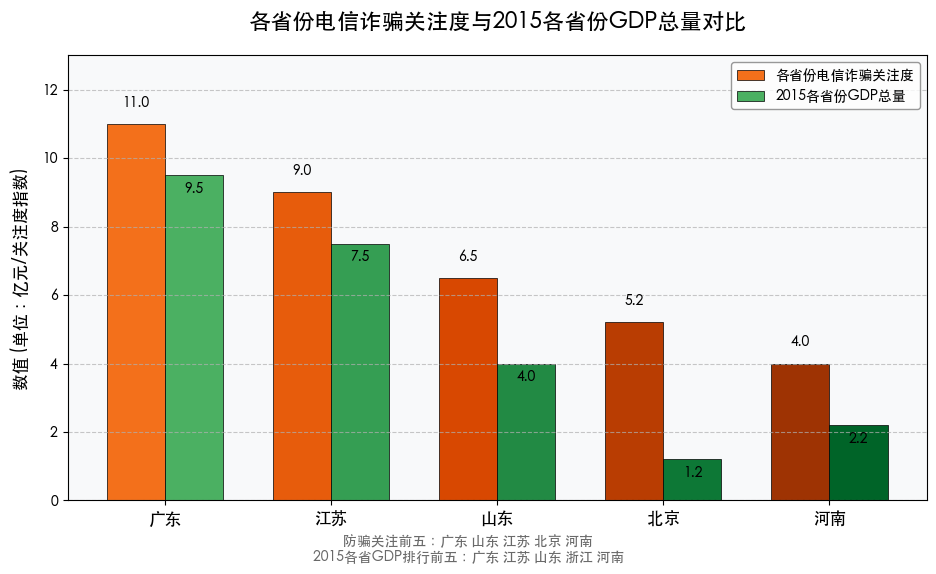

In [3]:
import matplotlib.pyplot as plt
import numpy as np


# 数据定义
provinces = ["广东", "江苏", "山东", "北京", "河南"]
fraud_attention = [11, 9, 6.5, 5.2, 4]
gdp_2015 = [9.5, 7.5, 4, 1.2, 2.2]

# 创建画布和子图
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(provinces))
width = 0.35

# 设置渐变色
colors1 = plt.cm.Oranges(np.linspace(0.6, 0.9, len(provinces)))
colors2 = plt.cm.Greens(np.linspace(0.6, 0.9, len(provinces)))

# 绘制带渐变色的柱状图
rects1 = ax.bar(x - width/2, fraud_attention, width, 
                label='各省份电信诈骗关注度', color=colors1, 
                edgecolor='black', linewidth=0.5)

rects2 = ax.bar(x + width/2, gdp_2015, width, 
                label='2015各省份GDP总量', color=colors2, 
                edgecolor='black', linewidth=0.5)

# 添加数值标签（优化位置和样式）
def add_labels(rects, ax, is_top=False):
    for rect in rects:
        height = rect.get_height()
        y_pos = height + 0.3 if not is_top else height - 0.3
        va = 'bottom' if not is_top else 'top'
        ax.annotate(f'{height}',
                    xy=(rect.get_x() + rect.get_width() / 2, y_pos),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va=va,
                    fontsize=10, fontweight='bold')

add_labels(rects1, ax)
add_labels(rects2, ax, is_top=True)

# 设置图表标题和坐标轴标签
ax.set_title("各省份电信诈骗关注度与2015各省份GDP总量对比", 
             fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel("数值 (单位：亿元/关注度指数)", fontsize=12, labelpad=10)

# 设置x轴和y轴样式
ax.set_xticks(x)
ax.set_xticklabels(provinces, fontsize=12, fontweight='bold')
ax.set_ylim(0, 13)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# 美化图例
legend = ax.legend(fontsize=10, frameon=True, loc='upper right')
frame = legend.get_frame()
frame.set_facecolor('white')
frame.set_edgecolor('gray')
frame.set_alpha(0.8)

# 添加底部文字说明（优化排版）
plt.figtext(0.5, 0.01, 
            "防骗关注前五：广东 山东 江苏 北京 河南\n"
            "2015各省GDP排行前五：广东 江苏 山东 浙江 河南", 
            ha="center", fontsize=10, color='dimgray')

# 添加背景色区分区域
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#ffffff')

# 调整布局
plt.tight_layout(pad=3)
plt.show()

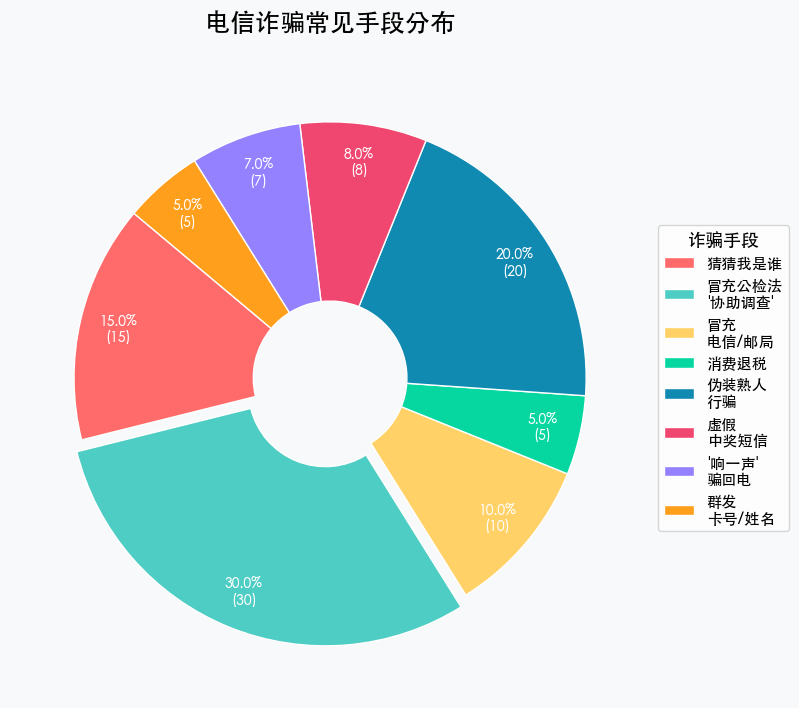

In [4]:
import matplotlib.pyplot as plt
import numpy as np

fraud_methods = [
    "猜猜我是谁", "冒充公检法\n'协助调查'", "冒充\n电信/邮局", "消费退税",
    "伪装熟人\n行骗", "虚假\n中奖短信", "'响一声'\n骗回电", "群发\n卡号/姓名"
]
values = np.array([15, 30, 10, 5, 20, 8, 7, 5])  # 使用更真实的数据比例
total = sum(values)

# 创建画布
fig, ax = plt.subplots(figsize=(10, 8), facecolor='#f8f9fa')
fig.patch.set_alpha(0.9)  # 设置画布透明度

# 定义爆炸效果，突出显示占比最大的部分
explode = [0.05 if v == max(values) else 0 for v in values]

# 自定义颜色方案（使用更鲜明的配色）
colors = [
    '#ff6b6b', '#4ecdc4', '#ffd166', '#06d6a0', 
    '#118ab2', '#ef476f', '#9381ff', '#ff9f1c'
]

# 绘制饼图
wedges, texts, autotexts = ax.pie(
    values,
    explode=explode,
    labels=None,  # 暂时不显示标签，通过图例展示
    autopct=lambda p: f'{p:.1f}%\n({int(p*total/100)})',  # 同时显示百分比和实际数量
    startangle=140,
    colors=colors,
    wedgeprops=dict(width=0.7, edgecolor='w', linewidth=1),  # 环形饼图效果
    pctdistance=0.85,  # 百分比标签位置
    textprops={'fontsize': 10, 'weight': 'bold', 'color': 'w'}
)

# 添加标题和副标题
ax.set_title("电信诈骗常见手段分布", fontsize=18, fontweight="bold", pad=20)

# 添加图例
legend = ax.legend(
    wedges, fraud_methods,
    title="诈骗手段",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=11,
    title_fontsize=13
)
legend.get_frame().set_alpha(0.8)  # 图例背景半透明

# 美化布局
plt.tight_layout(pad=4)  # 增加边距
plt.subplots_adjust(right=0.75)  # 为图例腾出空间

# 显示图表
plt.show()

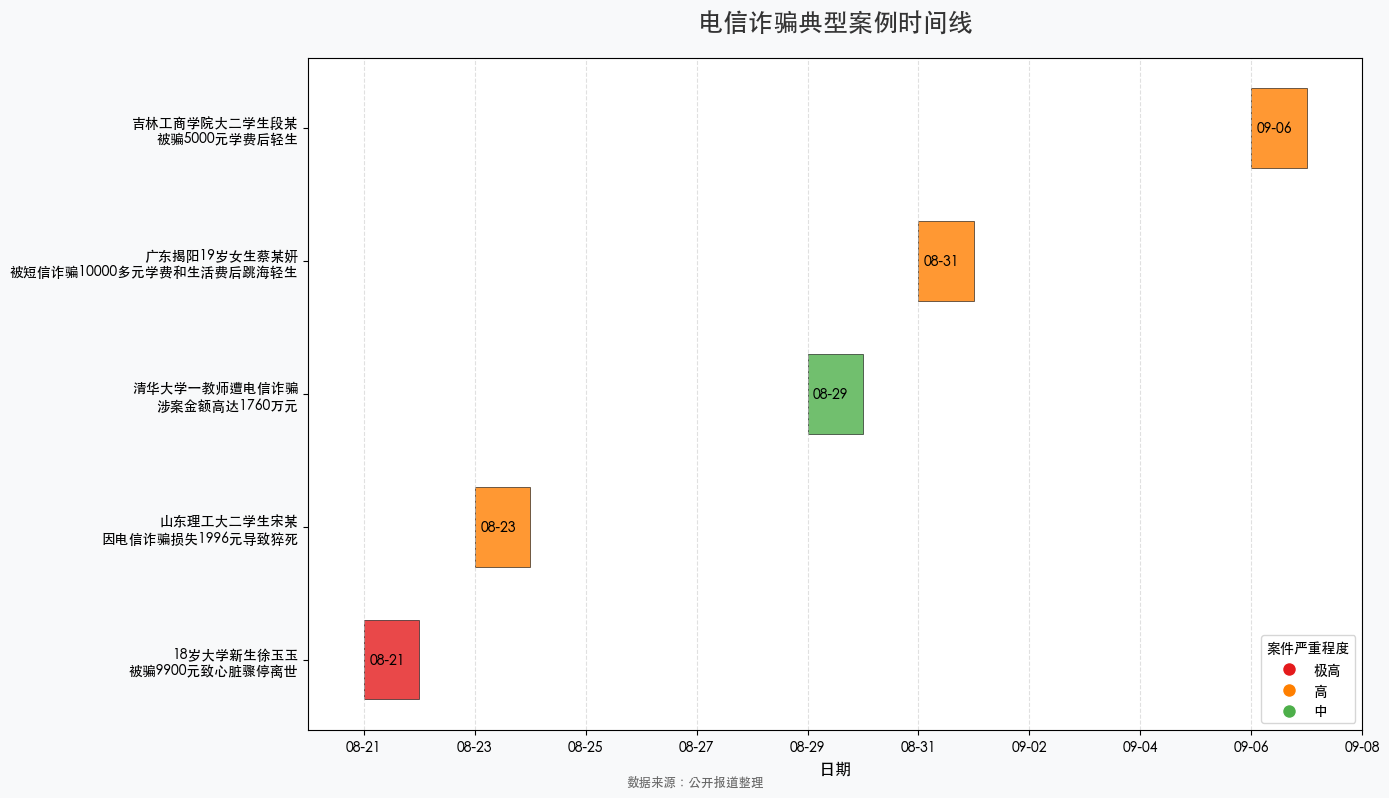

In [5]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import matplotlib.colors as mcolors
import numpy as np

# 提取图表内容
cases = [
    {
        "date": datetime(2024, 8, 21),
        "desc": "18岁大学新生徐玉玉\n被骗9900元致心脏骤停离世",
        "severity": "极高",  # 新增严重程度字段
        "color": "#e41a1c"  # 新增颜色映射
    },
    {
        "date": datetime(2024, 8, 23),
        "desc": "山东理工大二学生宋某\n因电信诈骗损失1996元导致猝死",
        "severity": "高",
        "color": "#ff7f00"
    },
    {
        "date": datetime(2024, 8, 29),
        "desc": "清华大学一教师遭电信诈骗\n涉案金额高达1760万元",
        "severity": "中",
        "color": "#4daf4a"
    },
    {
        "date": datetime(2024, 8, 31),
        "desc": "广东揭阳19岁女生蔡某妍\n被短信诈骗10000多元学费和生活费后跳海轻生",
        "severity": "高",
        "color": "#ff7f00"
    },
    {
        "date": datetime(2024, 9, 6),
        "desc": "吉林工商学院大二学生段某\n被骗5000元学费后轻生",
        "severity": "高",
        "color": "#ff7f00"
    }
]

# 拆分数据，方便绘图
dates = [case["date"] for case in cases]
descriptions = [case["desc"] for case in cases]
colors = [case["color"] for case in cases]
severities = [case["severity"] for case in cases]

# 创建画布
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('#f8f9fa')  # 设置画布背景色
ax.set_facecolor('#ffffff')  # 设置绘图区背景色

# 绘制水平条形图，根据严重程度设置颜色
y_ticks = range(len(descriptions))
bars = ax.barh(y_ticks, [1]*len(descriptions), 
               left=mdates.date2num(dates), 
               height=0.6, 
               color=colors,
               alpha=0.8,
               edgecolor='black',
               linewidth=0.5)

# 添加数据标签
for i, (date, bar) in enumerate(zip(dates, bars)):
    ax.text(mdates.date2num(date) + 0.1, i, 
            date.strftime('%m-%d'), 
            va='center', 
            fontsize=10,
            fontweight='bold')

# 设置x轴为日期格式
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))  # 间隔2天显示一个刻度
ax.set_xlabel("日期", fontsize=12, fontweight='bold')
ax.set_xlim(mdates.date2num(min(dates)) - 1, mdates.date2num(max(dates)) + 2)  # 调整x轴范围

# 设置y轴为案例描述
ax.set_yticks(y_ticks)
ax.set_yticklabels(descriptions, fontsize=10)

# 添加标题
ax.set_title("电信诈骗典型案例时间线", fontsize=18, fontweight="bold", pad=20)
ax.title.set_color('#333333')

# 添加网格
ax.grid(axis="x", linestyle="--", alpha=0.6, color='#cccccc')

# 添加严重程度图例
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', label='极高',
                          markerfacecolor='#e41a1c', markersize=10),
                   plt.Line2D([0], [0], marker='o', color='w', label='高',
                          markerfacecolor='#ff7f00', markersize=10),
                   plt.Line2D([0], [0], marker='o', color='w', label='中',
                          markerfacecolor='#4daf4a', markersize=10)]

ax.legend(handles=legend_elements, title='案件严重程度', loc='lower right')

# 添加底部注释
plt.figtext(0.5, 0.01, '数据来源：公开报道整理', ha='center', fontsize=9, color='#666666')

# 优化布局
plt.tight_layout()
plt.subplots_adjust(bottom=0.08)  # 调整底部边距
plt.show()    